# Naive Bayes, and the assumption it is named for

k-nearest neighbours made no assumptions and paid for it in dimensions. This
notebook takes the opposite bargain: a method that makes one **very strong**
assumption, and in exchange trains in a single pass and works in thousands of
dimensions without complaint.

The assumption is in the name, and it is almost always false. The interesting
question is not whether it holds — it does not — but **when being wrong about it
costs you nothing, and when it costs you everything**.

This notebook answers that with two datasets one step apart:

- on the pumps, Naive Bayes scores **0.933**, within a point of the best model
  in the lesson;
- on a second dataset, it scores **worse than guessing**.

Understanding which is which is the whole point, and it generalises far beyond
this one method.

In [1]:
# pip install numpy==1.26.4 pandas==2.1.1 matplotlib==3.8.0 scikit-learn==1.3.1

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from pump_data import load_interacting, load_pumps

FIGURES = Path.cwd().parent / "Figures"
FIGURES.mkdir(exist_ok=True)

BLUE, TEAL, RUST, GOLD = "#1F4E79", "#2E7D8A", "#9C4221", "#F0BE50"
INK, SLATE = "#1A1A1A", "#4A5568"
plt.rcParams.update({
    "font.size": 11, "axes.edgecolor": SLATE, "axes.labelcolor": INK,
    "text.color": INK, "xtick.color": SLATE, "ytick.color": SLATE,
})

folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

X, y = load_pumps()
print(f"{len(X)} pumps, {int(y.sum())} faulty ({y.mean():.1%})")

1200 pumps, 735 faulty (61.3%)


## 1. Bayes' rule, and where the difficulty is

We want the probability of a class given the readings. Bayes' rule turns it
round into things we can estimate from data:

$$P(y = c \mid x) = \frac{P(x \mid y = c)\,P(y = c)}{P(x)}$$

Three pieces. $P(y = c)$ is the **prior** — how common the class is, which is
just a count. $P(x)$ is the same for every class, so it cannot affect which
class wins and can be dropped.

That leaves $P(x \mid y = c)$: **the probability of seeing this exact
combination of readings, among pumps of that class.** This is where the whole
difficulty lives.

With two features it is a two-dimensional density and we could estimate it. With
twenty features it is a twenty-dimensional density, and there is no amount of
data that populates a twenty-dimensional space — which is the curse of
dimensionality from notebook 1, arriving from a completely different direction.

## 2. The naive assumption

Naive Bayes cuts that knot with one sentence:

> **Given the class, the features are independent of each other.**

If that is true, the joint probability factorises into a product of
one-dimensional ones:

$$P(x \mid y = c) = \prod_{j=1}^{n} P(x_j \mid y = c)$$

and each factor is a one-dimensional density estimated from the rows of that
class — trivial, no matter how many features there are.

**Why this is such a good bargain when it works.** The estimation problem goes
from one $n$-dimensional density to $n$ one-dimensional ones. Training is a
single pass counting means and variances, so it is fast; it needs very little
data per feature; and adding features costs almost nothing.

**Why it is almost never true.** In our pumps, vibration and pressure are both
driven by the operating point. In text, the word "New" is not independent of
"York" given the topic. In medicine, symptoms co-occur.

The claim is not that the assumption is true. It is that a model can be wrong
about the probabilities and still put the right class first — and section 4
shows exactly where that stops working.

## 3. On the pumps, it does very well

Gaussian Naive Bayes assumes each feature is normally distributed within each
class. Fit it and compare against the neighbours from notebook 1.

In [2]:
baseline = max(y.mean(), 1 - y.mean())

MODELS = {
    "majority baseline": None,
    "Gaussian Naive Bayes": GaussianNB(),
    "k-NN, k=5": KNeighborsClassifier(5),
    "logistic regression": LogisticRegression(max_iter=2_000),
}

for name, model in MODELS.items():
    if model is None:
        print(f"  {name:<24} {baseline:.3f}")
        continue
    scores = cross_val_score(make_pipeline(StandardScaler(), model), X, y,
                             cv=folds, scoring="accuracy")
    print(f"  {name:<24} {scores.mean():.3f} +/- {scores.std():.3f}")

  majority baseline        0.613
  Gaussian Naive Bayes     0.933 +/- 0.010
  k-NN, k=5                0.944 +/- 0.006
  logistic regression      0.613 +/- 0.000


**0.933**, a point behind k-NN and a very long way ahead of logistic
regression — despite drawing on an assumption we have just called almost always
false.

So let us check whether it is false *here*. The assumption is about the features
being independent **given the class**, which is not the same as being
independent overall.

In [3]:
print("correlation between the two readings")
print(f"  overall            {X.corr().iloc[0, 1]:+.3f}")
for label, name in ((0, "healthy"), (1, "faulty")):
    print(f"  within {name:<9}  {X[y == label].corr().iloc[0, 1]:+.3f}")

correlation between the two readings
  overall            -0.046
  within healthy    -0.006
  within faulty     -0.049


There is the answer. **Within each class the two readings are essentially
uncorrelated** — the numbers are within a few hundredths of zero.

That is not luck; it is how the data is generated. A pump's operating point
wanders around the design point in a way that treats the two readings
symmetrically, so once you know whether a pump is healthy, knowing its vibration
tells you very little extra about its pressure.

**Naive Bayes is doing well here because its assumption happens to be true.**
That is a much more useful thing to know than the score itself, because it tells
you when to expect the score to hold up.

## 4. One step away, it is worse than guessing

Now a second dataset from the same pump fleet, with two different sensors.

The physics: the pump is faulty when **exactly one** of the two readings is
high. Both high is the designed high-load mode; both low is idle; one without
the other is a mismatch between demand and delivery, and that is the fault.

Look at what that does to each sensor on its own.

In [4]:
Xi, yi = load_interacting()
print(f"{len(Xi)} pumps, {int(yi.sum())} faulty ({yi.mean():.1%})")
print("\nhow much each sensor tells you on its own:")
for column in Xi.columns:
    print(f"  correlation of {column} with the label: "
          f"{Xi[column].corr(yi):+.3f}")

print("\nand the means, per class:")
print(Xi.groupby(yi).mean().round(3).to_string())

1200 pumps, 628 faulty (52.3%)

how much each sensor tells you on its own:
  correlation of sensor_a with the label: +0.081
  correlation of sensor_b with the label: -0.064

and the means, per class:
        sensor_a  sensor_b
faulty                    
0         -0.012    -0.006
1          0.167    -0.149


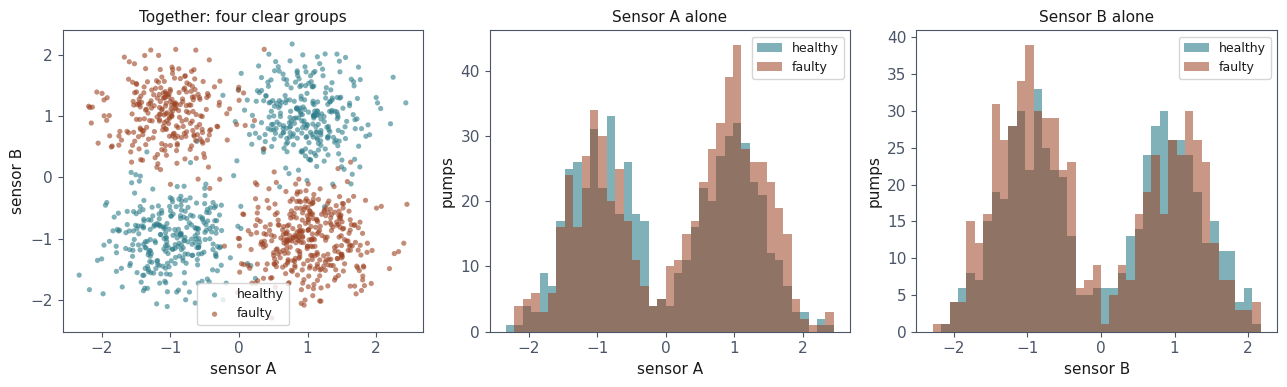

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.0))

axes[0].scatter(Xi.loc[yi == 0, "sensor_a"], Xi.loc[yi == 0, "sensor_b"],
                s=14, color=TEAL, alpha=.6, label="healthy", edgecolor="none")
axes[0].scatter(Xi.loc[yi == 1, "sensor_a"], Xi.loc[yi == 1, "sensor_b"],
                s=14, color=RUST, alpha=.6, label="faulty", edgecolor="none")
axes[0].set_xlabel("sensor A"); axes[0].set_ylabel("sensor B")
axes[0].set_title("Together: four clear groups", fontsize=11)
axes[0].legend(fontsize=9)

for ax, column, label, title in ((axes[1], "sensor_a", "sensor A", "Sensor A alone"),
                                 (axes[2], "sensor_b", "sensor B", "Sensor B alone")):
    bins = np.linspace(Xi[column].min(), Xi[column].max(), 40)
    ax.hist(Xi.loc[yi == 0, column], bins=bins, color=TEAL, alpha=.6,
            label="healthy")
    ax.hist(Xi.loc[yi == 1, column], bins=bins, color=RUST, alpha=.55,
            label="faulty")
    ax.set_xlabel(label); ax.set_ylabel("pumps")
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)

fig.tight_layout()
fig.savefig(FIGURES / "interaction_marginals.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()

The left panel shows four distinct groups and a perfectly learnable rule.

The middle and right panels show what Naive Bayes gets to see: **each sensor on
its own, where the two histograms sit almost exactly on top of each other.**

Almost, not exactly, and the residue matters. The class means differ by about
0.17 against a spread of roughly 1 — a difference produced by nothing but the
finite sample. Hold on to that: it is what the next result is made of.

Naive Bayes estimates $P(\text{sensor A} \mid \text{class})$ and
$P(\text{sensor B} \mid \text{class})$ and multiplies them. Both factors are the
same for both classes. There is nothing to multiply.

In [6]:
print(f"  majority baseline        {max(yi.mean(), 1 - yi.mean()):.3f}\n")
for name, model in (("Gaussian Naive Bayes", GaussianNB()),
                    ("logistic regression", LogisticRegression(max_iter=2_000)),
                    ("SVM, linear kernel", SVC(kernel="linear")),
                    ("k-NN, k=5", KNeighborsClassifier(5)),
                    ("SVM, RBF kernel", SVC(kernel="rbf"))):
    scores = cross_val_score(make_pipeline(StandardScaler(), model), Xi, yi,
                             cv=folds, scoring="accuracy")
    print(f"  {name:<24} {scores.mean():.3f} +/- {scores.std():.3f}")

  majority baseline        0.523

  Gaussian Naive Bayes     0.404 +/- 0.017
  logistic regression      0.393 +/- 0.011
  SVM, linear kernel       0.606 +/- 0.071
  k-NN, k=5                0.967 +/- 0.008
  SVM, RBF kernel          0.972 +/- 0.008


**0.404.** Not merely useless — *worse than a coin flip*, and well below the
0.523 you would get by always predicting the majority class.

Being below chance is worth a moment's thought, because it looks impossible. The
sensors are not exactly uninformative in this finite sample: each carries a
correlation of a few hundredths with the label, pure noise, pointing in some
direction. Naive Bayes has nothing else to work with, so it leans on that
accident — and in this sample the accident points the wrong way.

A model with no signal does not sit politely at 50%. It follows whatever
spurious structure it can find.

Note also which models cope. **k-NN and the radial basis function (RBF)
support vector machine (SVM) score above 0.96**, because
neither of them factorises anything: they work with points in the plane, where
the four groups are obvious. Logistic regression fails for a different reason —
no straight line separates the diagonal groups — and that is what notebook 3 is
about.

## 5. It cannot even tell that it is lost

One more measurement, because it changes how you would use this model in
practice.

A well-behaved model that is unsure should say so. Let us compare how confident
Naive Bayes is when it happens to be right against when it is wrong.

In [7]:
Xtr, Xte, ytr, yte = train_test_split(Xi, yi, test_size=0.25,
                                      random_state=0, stratify=yi)
nb = make_pipeline(StandardScaler(), GaussianNB()).fit(Xtr, ytr)
proba = nb.predict_proba(Xte)[:, 1]
prediction = (proba >= 0.5).astype(int)

correct = prediction == yte.to_numpy()
confidence = np.maximum(proba, 1 - proba)

print(f"mean confidence when right : {confidence[correct].mean():.3f}")
print(f"mean confidence when wrong : {confidence[~correct].mean():.3f}")
print(f"highest confidence reached : {confidence.max():.3f}")

mean confidence when right : 0.567
mean confidence when wrong : 0.555
highest confidence reached : 0.673


The two numbers are nearly identical. Naive Bayes is **equally unsure whether
it is right or wrong**, which at least is honest — but it means the probability
it reports carries no information about whether to trust the prediction.

Worth contrasting with the usual complaint about Naive Bayes, which is the
opposite one. When features are *correlated*, multiplying their probabilities
counts the same evidence several times over, and the model becomes wildly
overconfident — probabilities pinned at 0.999 with an accuracy nothing like
that. Lesson 5's point about calibration applies directly: **the ranking can be
useful while the probabilities are not**, and Naive Bayes is the classic example
of that gap.

## 6. When to reach for it anyway

Given all that, Naive Bayes remains genuinely useful, and it is worth being
specific about when.

**Very high dimensions with little data.** Text classification is the canonical
case: tens of thousands of word-count features, and the assumption that words
are independent given the topic is transparently false. It works anyway, because
each individual estimate is one number from a handful of counts, and being
roughly right in ten thousand dimensions beats being unable to estimate anything
at all.

**As a baseline.** It trains in one pass over the data. If your carefully tuned
model does not beat Naive Bayes, you have learned something important quickly
and cheaply.

**When the class ranking is what you need**, and the probabilities are not going
to be used as probabilities.

**And the one case to avoid it:** when the signal is an interaction, as in
section 4. No amount of data fixes that, because the model has no way to
represent what you are asking it to learn.

## What to take away

- **Bayes' rule is easy; the joint density is the hard part.** The naive
  assumption replaces one $n$-dimensional estimate with $n$ one-dimensional
  ones.
- **The assumption is about independence *given the class*.** On the pumps it
  holds almost exactly, which is why the method scores 0.933.
- **Where the signal is an interaction, it scores 0.404** — below chance, because
  with no real per-feature evidence it leans on the spurious kind.
- **A model with no signal does not sit at 50%.** It follows whatever accident it
  can find.
- **Its probabilities are not to be trusted as probabilities**, whichever
  direction the miscalibration runs.
- It remains the right tool in **high dimensions with little data**, and it is
  always a cheap baseline.

Notebook 3 takes the third approach: rather than remembering the data or
assuming its structure, bend the space until a straight line works after all.